In [1]:
# Show plots inline, and load main getdist plot module and samples class
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sys, os
sys.path.insert(0,os.path.realpath(os.path.join(os.getcwd(),'..')))
from getdist import plots, MCSamples
import getdist
import camb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import IPython
print('GetDist Version: %s, Matplotlib version: %s'%(getdist.__version__, plt.matplotlib.__version__))

/home/andrewcats/anaconda3/envs/conda_andrea_g/lib/python3.9/site-packages/numpy/_core/getlimits.py:545: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


GetDist Version: 1.5.4, Matplotlib version: 3.9.2


In [2]:
# Loading samples
#lcdm:
chain_lcdm = os.path.join('/home/andrewcats/tesi_magistrale/lcdm/act_all', '1_lcdm_act_planck_desidr2_des')
samples_lcdm = getdist.mcsamples.loadMCSamples(file_root=chain_lcdm, settings={'ignore_rows':0.3})
#print('Parameters: ', samples.paramNames.names)
param_names_lcdm = [param.name for param in samples_lcdm.paramNames.names]
print(param_names_lcdm)

#w0wacdm:
chain_w0wa = os.path.join('/home/andrewcats/tesi_magistrale/w0wacdm/act_all', '1_w0wa_act_planck_desidr2_des')
samples_w0wa = getdist.mcsamples.loadMCSamples(file_root=chain_w0wa, settings={'ignore_rows':0.3})
#print('Parameters: ', samples.paramNames.names)
param_names_w0wa = [param.name for param in samples_w0wa.paramNames.names]
print(param_names_w0wa)

#EFT_exp:
chain_exp = os.path.join('/home/andrewcats/tesi_magistrale/eftcamb/eftcamb_exponential/lcdm_eft_exp/act_all', '1_EXP_act_planck_desidr2_des')
samples_exp = getdist.mcsamples.loadMCSamples(file_root=chain_exp, settings={'ignore_rows':0.3})
#print('Parameters: ', samples.paramNames.names)
param_names_exp = [param.name for param in samples_exp.paramNames.names]
print(param_names_exp)


['H0', 'logA', 'ns', 'ombh2', 'omch2', 'tau', 'A_act', 'P_act', 'A', 'As', 'DHBBN', 'YHe', 'Y_p', 'age', 'clamp', 'omega_de', 'omegam', 'omegamh2', 'rdrag', 's8h5', 'S8_optimal', 's8omegamp25', 's8omegamp5', 'sigma8', 'thetastar', 'zrei', 'A_planck', 'chi2__BAO', 'chi2__CMB', 'chi2__SN', 'chi2', 'chi2__planck_2018_lowl.TT', 'chi2__planck_2018_lowl.EE_sroll2', 'chi2__act_dr6_cmbonly.PlanckActCut', 'chi2__act_dr6_cmbonly', 'chi2__bao.desi_dr2.desi_bao_all', 'chi2__sn.desy5']
['H0', 'logA', 'ns', 'ombh2', 'omch2', 'tau', 'w', 'wa', 'A_act', 'P_act', 'A', 'As', 'DHBBN', 'YHe', 'Y_p', 'age', 'clamp', 'omega_de', 'omegam', 'omegamh2', 'rdrag', 's8h5', 'S8_optimal', 's8omegamp25', 's8omegamp5', 'sigma8', 'thetastar', 'zrei', 'A_planck', 'chi2__BAO', 'chi2__CMB', 'chi2__SN', 'chi2', 'chi2__planck_2018_lowl.TT', 'chi2__planck_2018_lowl.EE_sroll2', 'chi2__act_dr6_cmbonly.PlanckActCut', 'chi2__act_dr6_cmbonly', 'chi2__bao.desi_dr2.desi_bao_all', 'chi2__sn.desy5']
['H0', 'logA', 'ns', 'ombh2', 'om

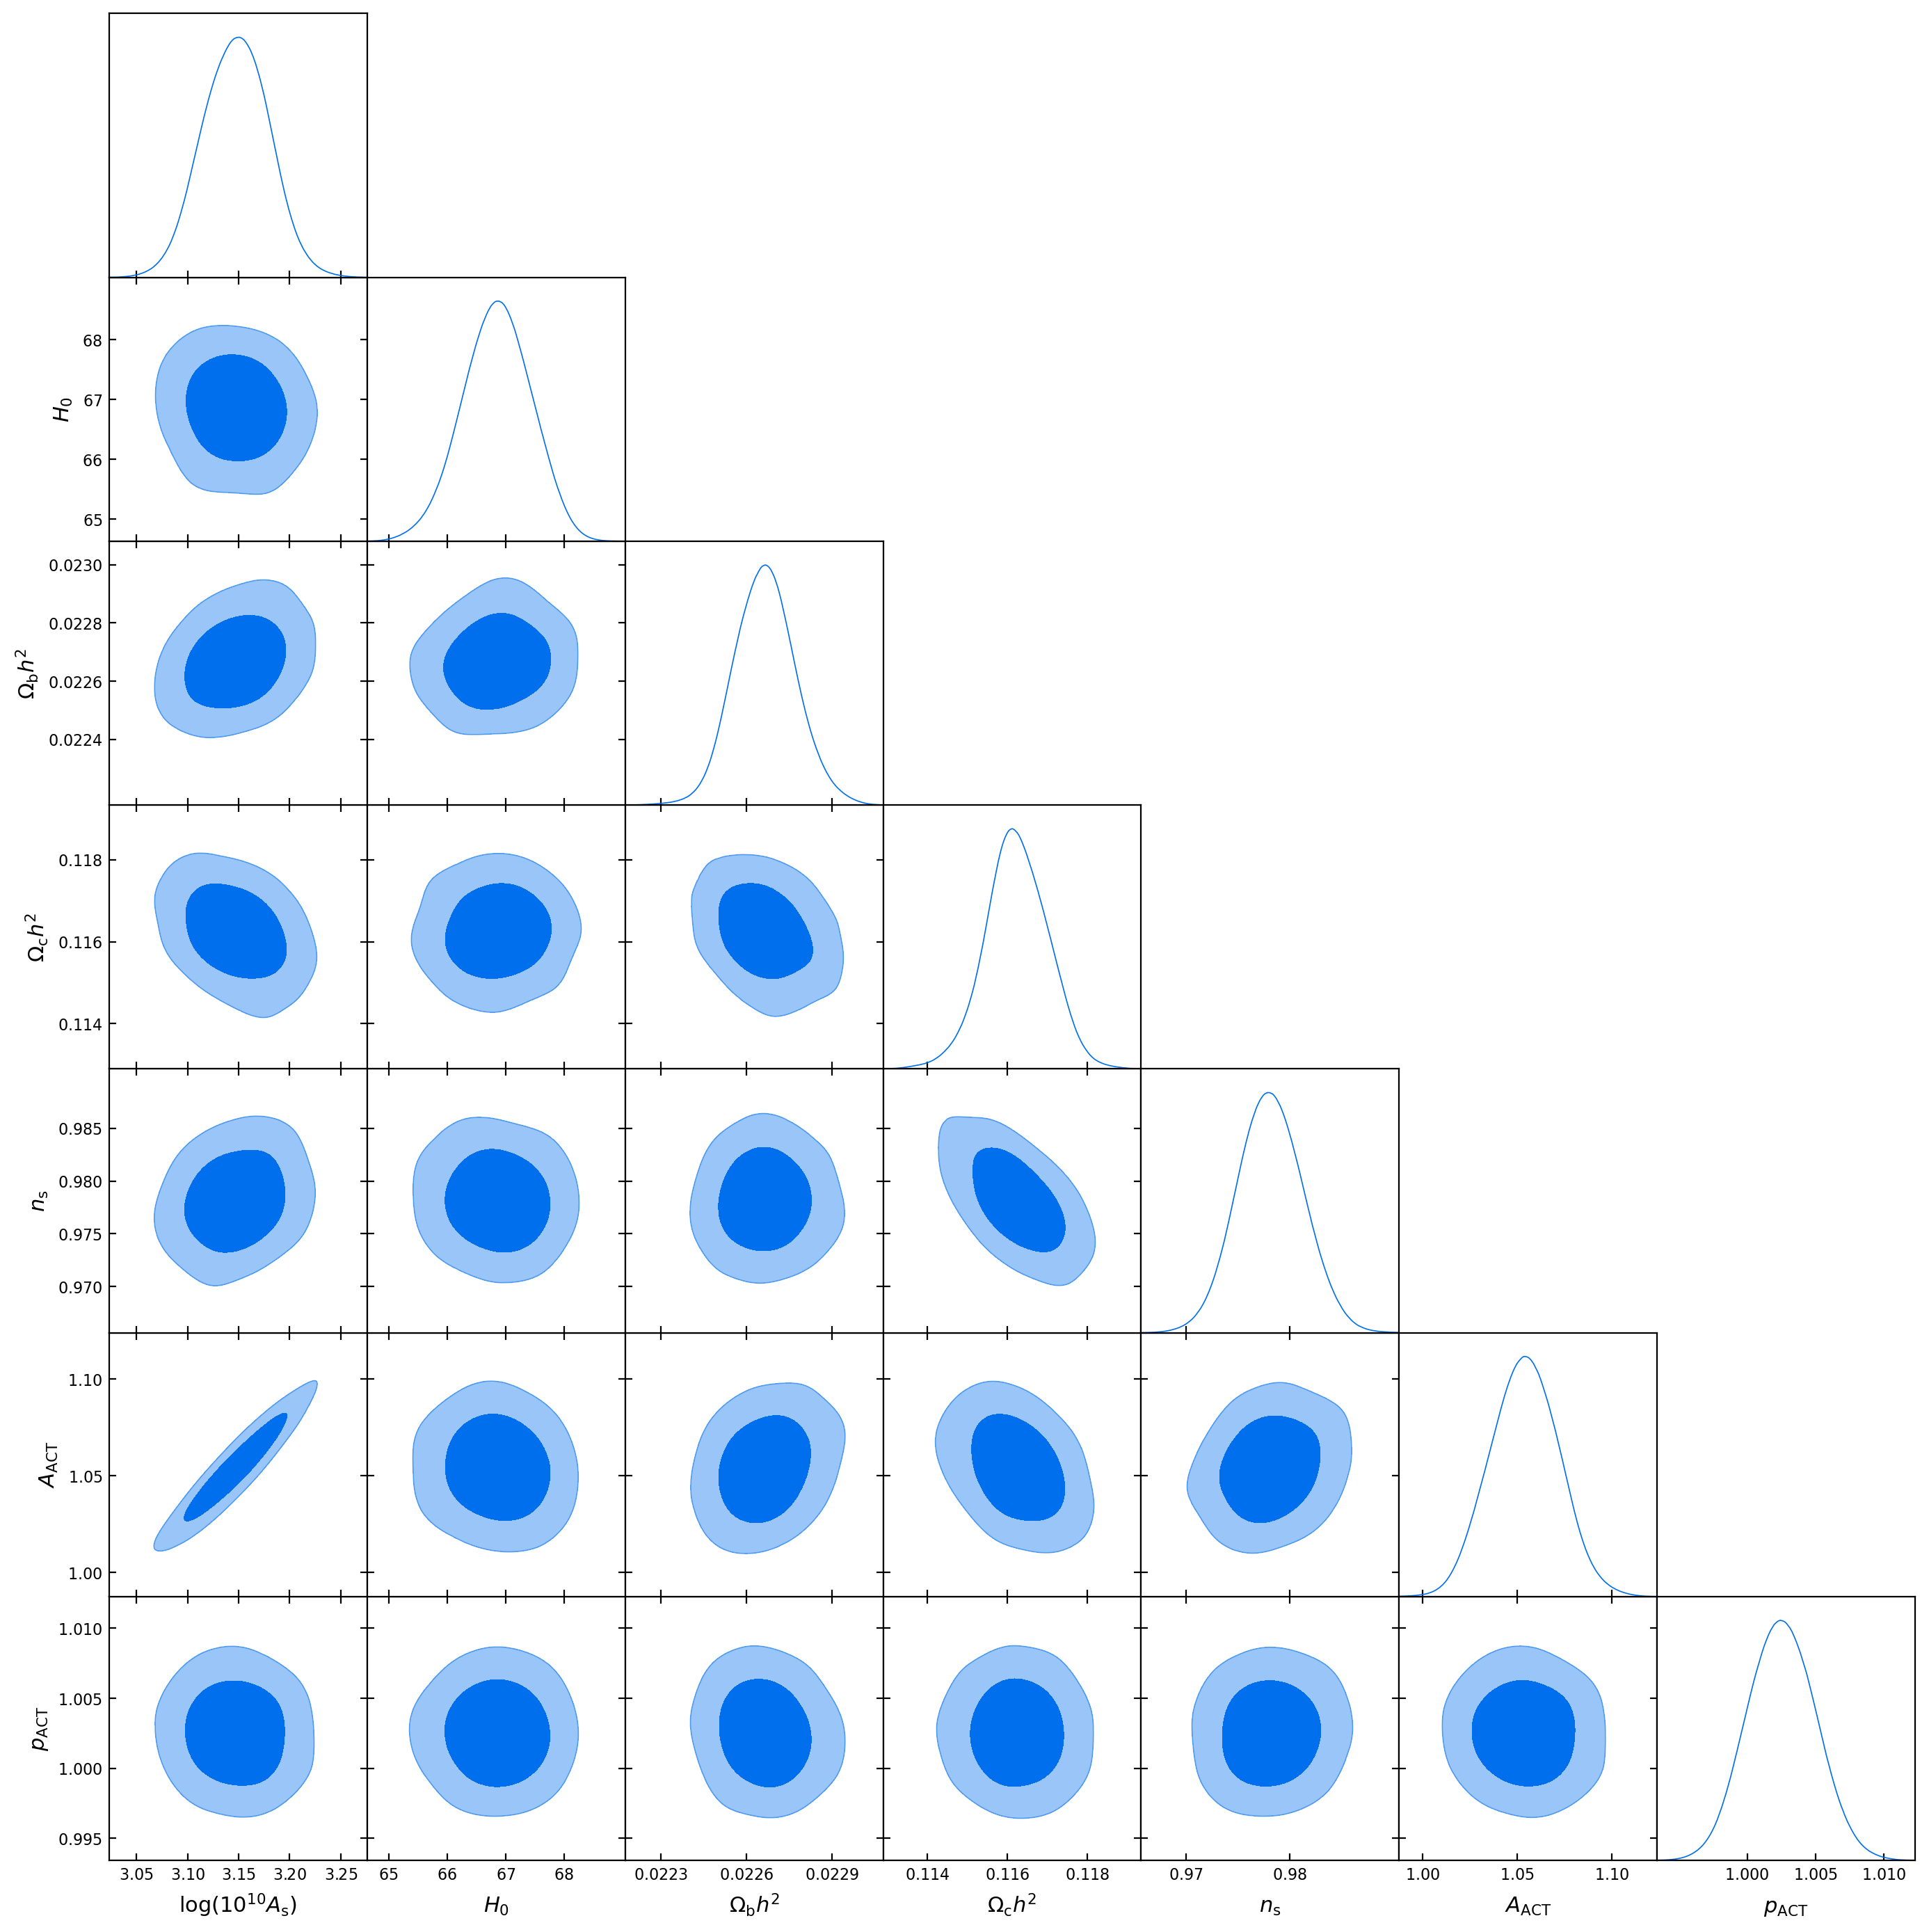

In [3]:
g2 = plots.get_subplot_plotter()
g2.triangle_plot(samples_exp, ['logA', 'H0', 'ombh2', 'omch2', 'ns', 'A_act', 'P_act'], filled=True)

"\n# Triangle Plot of parameters: log(10^10*As), H0, ombh2, omch2, ns, A_act, P_act:\ng2 = plots.get_subplot_plotter()\ng2.triangle_plot(samples, ['logA', 'H0', 'ombh2', 'omch2', 'ns', 'A_act', 'P_act'], filled=True)\ng2.add_legend(['LCDM', 'w0wa', 'EFT_exp'])\n"

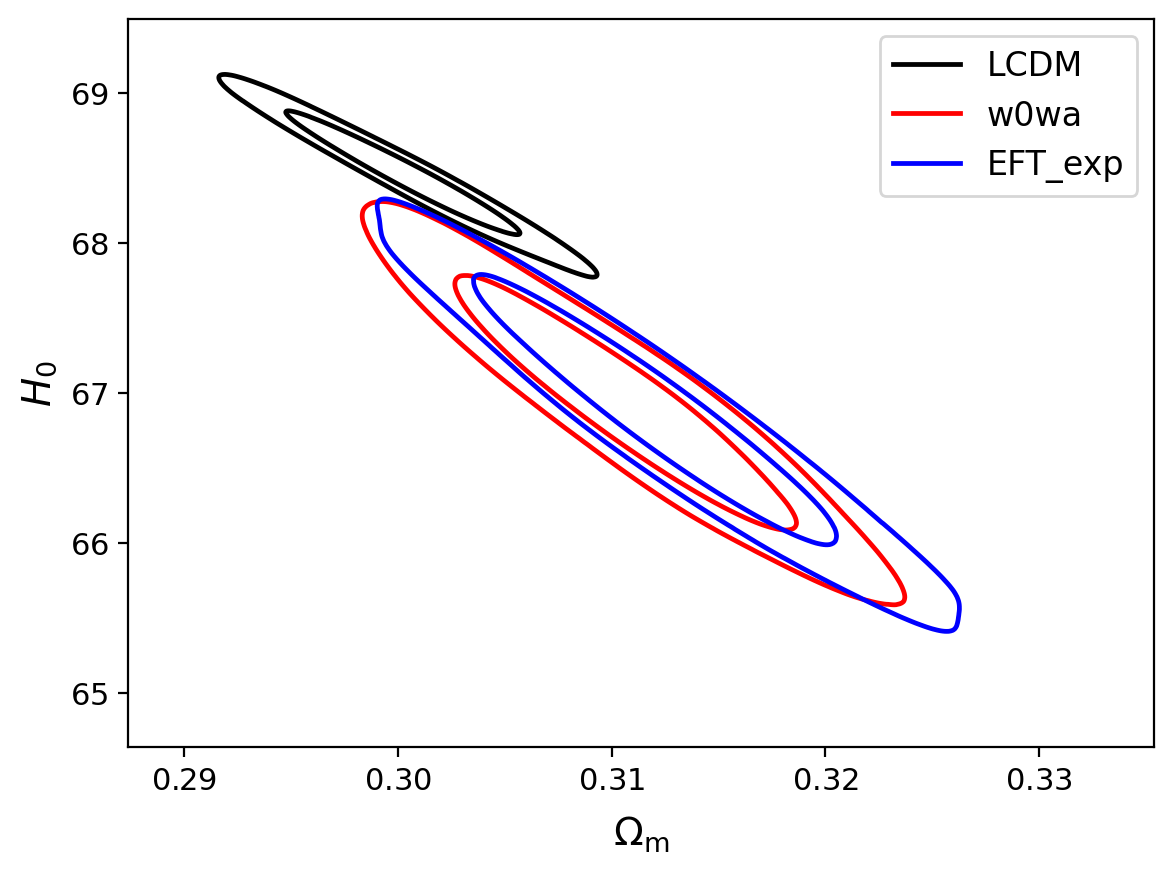

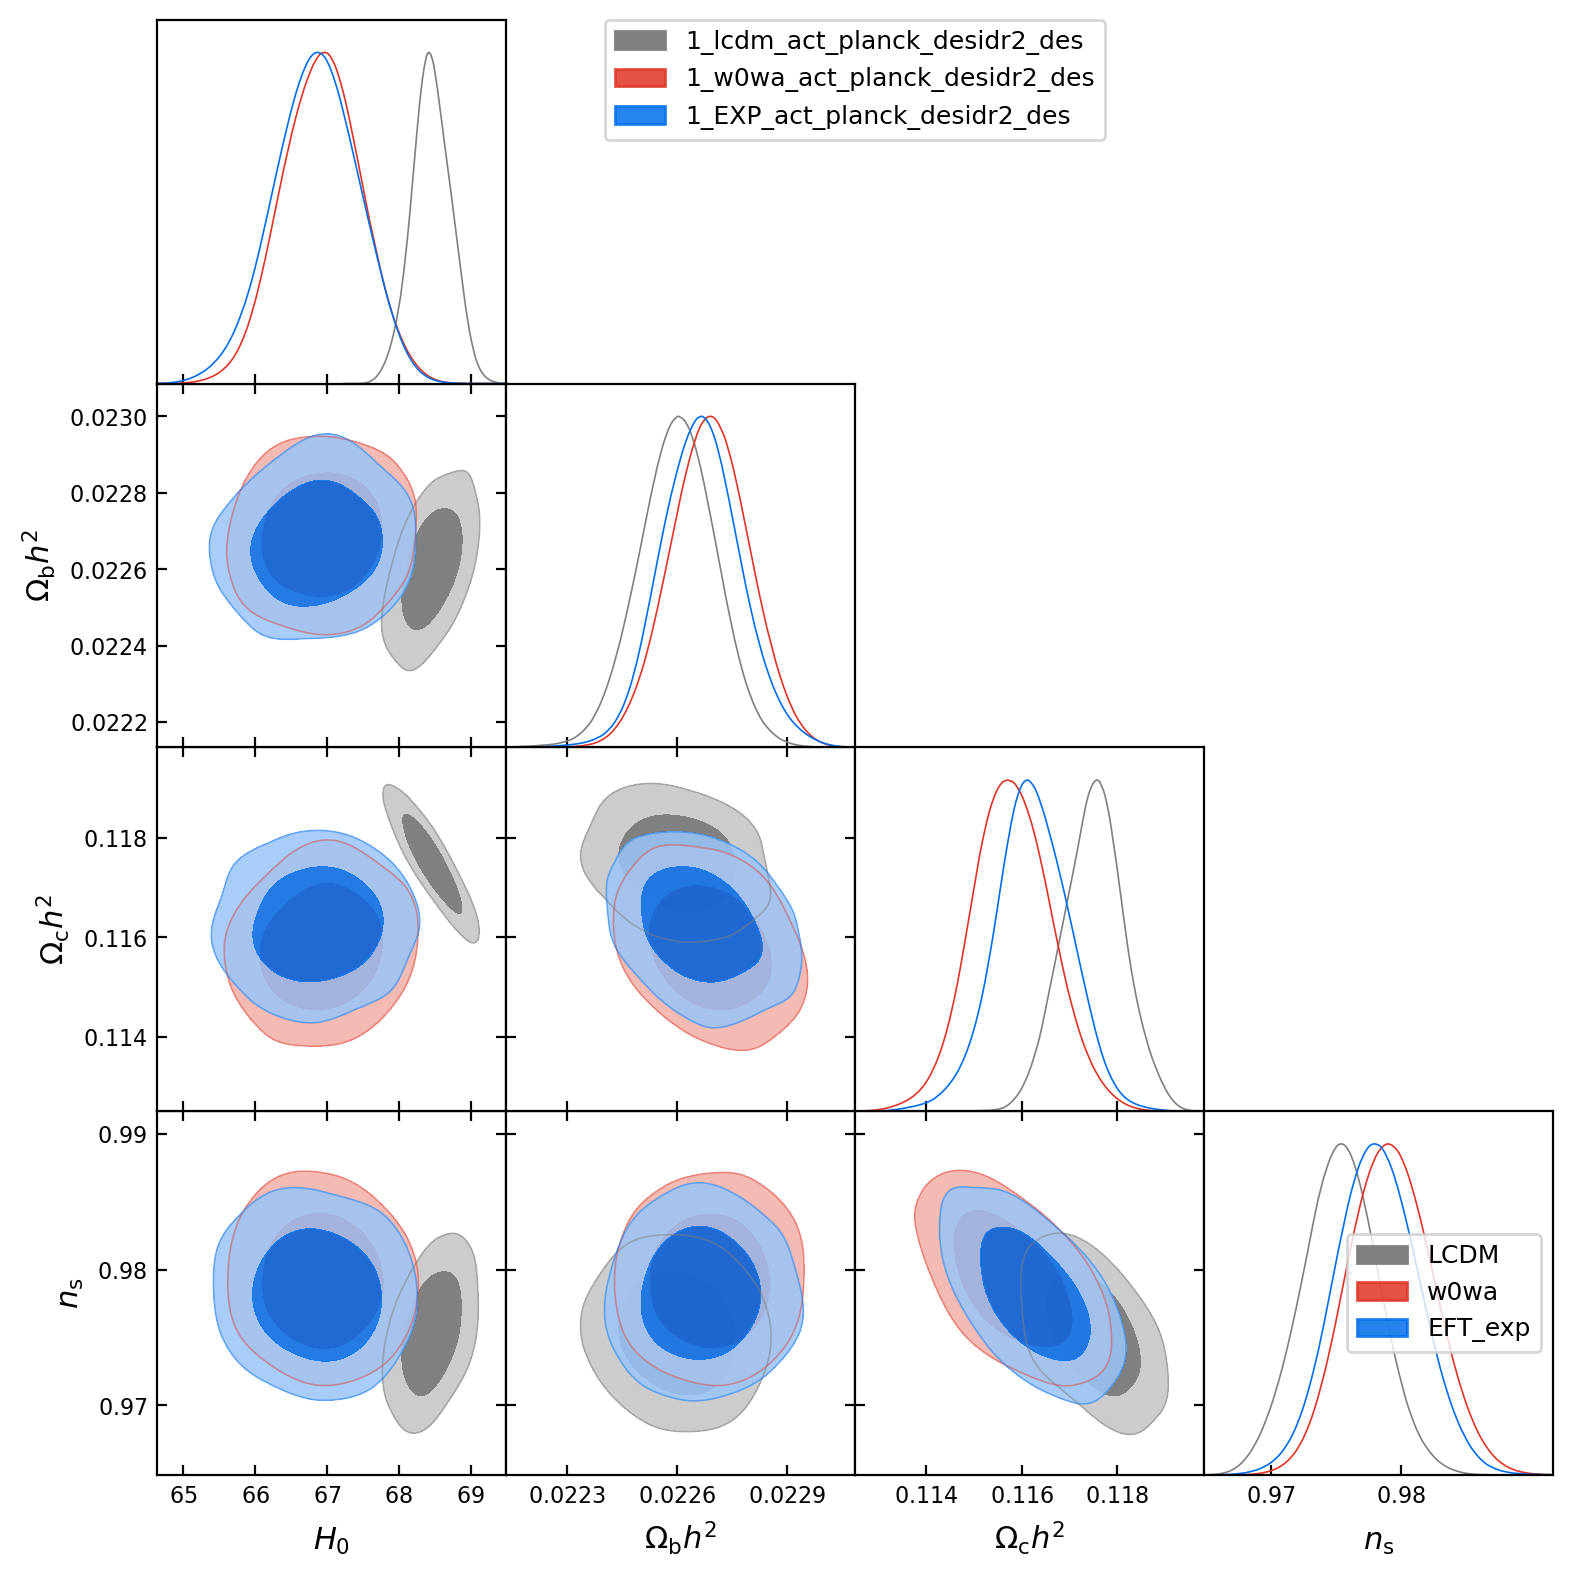

In [4]:
# Comparing 3 samples in the same plot
# lcdm vs w0wa vs exp
samples = [samples_lcdm, samples_w0wa, samples_exp]
g = plots.get_single_plotter()
g.plot_2d(samples, ['omegam', 'H0'])
g.add_legend(['LCDM', 'w0wa', 'EFT_exp'])

g1 = plots.get_subplot_plotter()
g1.triangle_plot(samples, ['H0', 'ombh2', 'omch2', 'ns'], filled=True)
g1.add_legend(['LCDM', 'w0wa', 'EFT_exp'])
'''
# Triangle Plot of parameters: log(10^10*As), H0, ombh2, omch2, ns, A_act, P_act:
g2 = plots.get_subplot_plotter()
g2.triangle_plot(samples, ['logA', 'H0', 'ombh2', 'omch2', 'ns', 'A_act', 'P_act'], filled=True)
g2.add_legend(['LCDM', 'w0wa', 'EFT_exp'])
'''

### Test BIC Method

In [5]:
# BISOGNA VEDERE COME HO FATTO IN MODEL_COMPARISON.IPYNB

### Find parameter of EFTCAMB
**Remember**:
A **confidence interval** tells you the range of values that are most compatible with your data, given a statistical model. 

For example, in the case of contour plot:

The inner (darker) contour corresponds to the 68% confidence region

The outer (lighter) contour corresponds to the 95% confidence region

(In a few words the meaning is: If I repeated this experiment many times, about 68% of the intervals I compute would contain the true value of the parameter.)

In [6]:
# Get the MargeStats object
marg_stats = samples_exp.getMargeStats()

# Get statistics for the parameter 'EFT_lambda'
lambda_stats = marg_stats.parWithName('EFT_lambda')

# Extract values
mean = lambda_stats.mean
limits = lambda_stats.limits

# Check limit type
if limits[1].lower is None:
    # One-sided upper bound
    upper = limits[1].upper
    print(f"EFT_lambda < {upper:.3f} at 95% CL (mean = {mean:.3f})")
else:
    lower = limits[1].lower
    upper = limits[1].upper
    print(f"EFT_lambda mean: {mean:.3f}")
    print(f"95% confidence interval: [{lower:.3f}, {upper:.3f}]")

# Use limits[0] → this is the 68% confidence interval
limits_68 = lambda_stats.limits[0]

# Check if it's one-sided or two-sided
if limits_68.lower is None:
    print(f"EFT_lambda < {limits_68.upper:.3f} at 68% CL (mean = {mean:.3f})")
elif limits_68.upper is None:
    print(f"EFT_lambda > {limits_68.lower:.3f} at 68% CL (mean = {mean:.3f})")
else:
    #print(f"EFT_lambda mean: {mean:.3f}")
    print(f"68% confidence interval: [{limits_68.lower:.3f}, {limits_68.upper:.3f}]")


EFT_lambda mean: 0.852
95% confidence interval: [0.558, 1.113]
68% confidence interval: [0.733, 1.007]


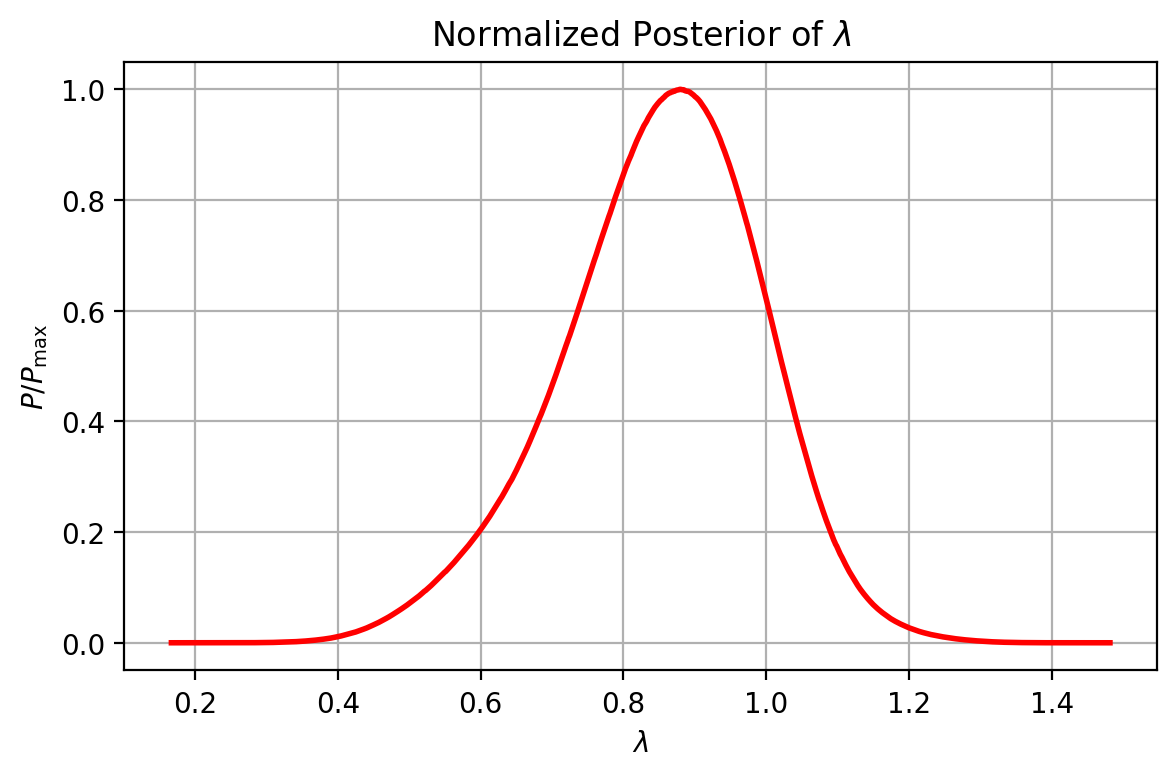

In [7]:
density = samples_exp.get1DDensity('EFT_lambda')

# x: parameter values
lambda_vals = density.x

# y: marginalized posterior values 
P_lambda = density.P

# Normalize to peak
P_lambda_norm = P_lambda / np.max(P_lambda)


plt.figure(figsize=(6, 4))
plt.plot(lambda_vals, P_lambda_norm, color='red', lw=2)
plt.xlabel(r'$\lambda$')
plt.ylabel(r'$P / P_{\max}$')
plt.title('Normalized Posterior of $\lambda$')
plt.grid(True)
plt.tight_layout()
plt.show()


### $\Delta \phi$

In [8]:
# Proof:
omega_lambda = 0.69
lambda_val = 0.8
sqrt_omega = np.sqrt(omega_lambda)
ln_term = np.log((1 + sqrt_omega) / (1 - sqrt_omega))
delta_phi_val = (lambda_val / 3.0) * (ln_term / sqrt_omega - 2)
print(f"delta_phi: {delta_phi_val:.3f}")

delta_phi: 0.231


In [ ]:

# Extract EFT_lambda and Omega_lambda samples
lambda_samples = samples_exp.samples[:, samples_exp.index['EFT_lambda']]
omega_lambda = samples_exp.samples[:, samples_exp.index['omega_de']]

# Compute Delta_phi for each sample
sqrt_omega = np.sqrt(omega_lambda)
ln_term = np.log((1 + sqrt_omega) / (1 - sqrt_omega))
delta_phi_samples = (lambda_samples / 3.0) * (ln_term / sqrt_omega - 2)

# Add Δφ as a derived parameter to the MCSamples object
samples_exp.addDerived(
    delta_phi_samples,
    name='delta_phi',
    label=r'\Delta\phi'
)

# Update internal stats (mean, limits, etc.)
samples_exp.updateBaseStatistics()



Delta phi:
Mean = 0.24362720000550306


AttributeError: 'ParamInfo' object has no attribute 'confidenceLimits'

In [16]:
# Get marginal statistics for all parameters
stats = samples_exp.getMargeStats()

# Extract statistics for delta_phi
dphi_stats = stats.parWithName('delta_phi')

print("Delta phi:")
print("Mean =", dphi_stats.mean)
print("68% CL lower =", dphi_stats.limits[0].lower)
print("68% CL upper =", dphi_stats.limits[0].upper)
print("95% CL lower =", dphi_stats.limits[1].lower)
print("95% CL upper =", dphi_stats.limits[1].upper)



Delta phi:
Mean = 0.24362720000550306
68% CL lower = 0.21366468176536585
68% CL upper = 0.28548763276292133
95% CL lower = 0.16430505197168138
95% CL upper = 0.31201065824659197


Delta_phi mean: 0.243
95% CL: [0.162, 0.303]
68% CL: [0.208, 0.278]


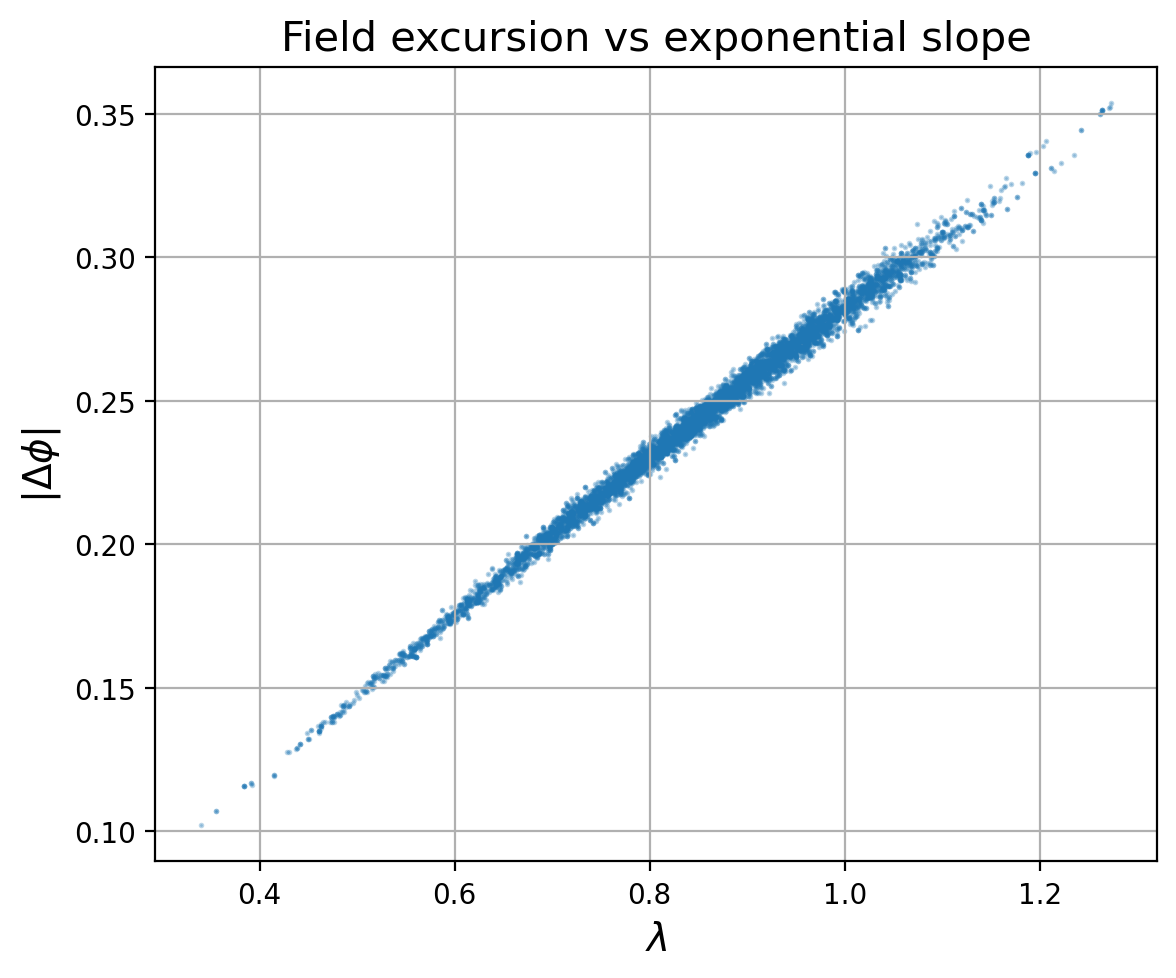

In [15]:
# Compute mean
mean = np.mean(delta_phi_samples)

# Compute 95% confidence interval (equal-tailed)
lower_95, upper_95 = np.percentile(delta_phi_samples, [2.5, 97.5])
lower_68, upper_68 = np.percentile(delta_phi_samples, [16, 84])

# Print results
print(f"Delta_phi mean: {mean:.3f}")
print(f"95% CL: [{lower_95:.3f}, {upper_95:.3f}]")
print(f"68% CL: [{lower_68:.3f}, {upper_68:.3f}]")

plt.figure(figsize=(6, 5))
plt.scatter(lambda_samples, delta_phi_samples, s=1, alpha=0.3)
plt.xlabel(r"$\lambda$", fontsize=14)
plt.ylabel(r"$|\Delta\phi|$", fontsize=14)
plt.title(r"Field excursion vs exponential slope", fontsize=15)
plt.grid(True)
plt.tight_layout()
plt.show()